In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Load clean data
df = pd.read_csv('../data/processed/churn_clean.csv')

# Encode categorical columns fresh
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Save fresh encoders (overwrites old ones)
joblib.dump(le_dict, '../models/label_encoders.pkl')

# Engineer features
df['EngagementScore'] = df['HourSpendOnApp']*0.4 + df['OrderCount']*0.4 + df['CouponUsed']*0.2
df['IsInactive']      = (df['DaySinceLastOrder'] >= 7).astype(int)
df['IsHighValue']     = (df['CashbackAmount'] >= df['CashbackAmount'].median()).astype(int)
df['ComplainLowSat']  = ((df['Complain'] == 1) & (df['SatisfactionScore'] <= 2)).astype(int)

# Split
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

# Save
joblib.dump(scaler,             '../models/scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_columns.pkl')

print("Everything ready ✓")
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Everything ready ✓
Train: (7492, 22), Test: (1126, 22)


In [5]:
# Model 1: Logistic Regression (baseline)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_sm)
print("Logistic Regression trained ✓")

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_sm)
print("Random Forest trained ✓")

# Model 3: XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_scaled, y_train_sm)
print("XGBoost trained ✓")

Logistic Regression trained ✓
Random Forest trained ✓
XGBoost trained ✓


In [7]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1 Score':  round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob),   4)
    }

results = [
    evaluate_model(lr,  X_test_scaled, y_test, 'Logistic Regression'),
    evaluate_model(rf,  X_test_scaled, y_test, 'Random Forest'),
    evaluate_model(xgb, X_test_scaled, y_test, 'XGBoost'),
]

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8117     0.4599  0.6632    0.5431   0.8298
      Random Forest    0.9787     0.9323  0.9421    0.9372   0.9968
            XGBoost    0.9547     0.8528  0.8842    0.8682   0.9860


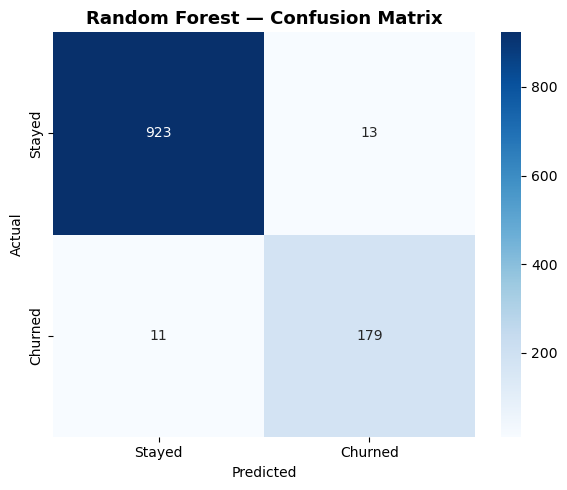

              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99       936
     Churned       0.93      0.94      0.94       190

    accuracy                           0.98      1126
   macro avg       0.96      0.96      0.96      1126
weighted avg       0.98      0.98      0.98      1126



In [9]:
y_pred_rf = rf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)

ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/processed/plot_07_confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred_rf,
      target_names=['Stayed', 'Churned']))

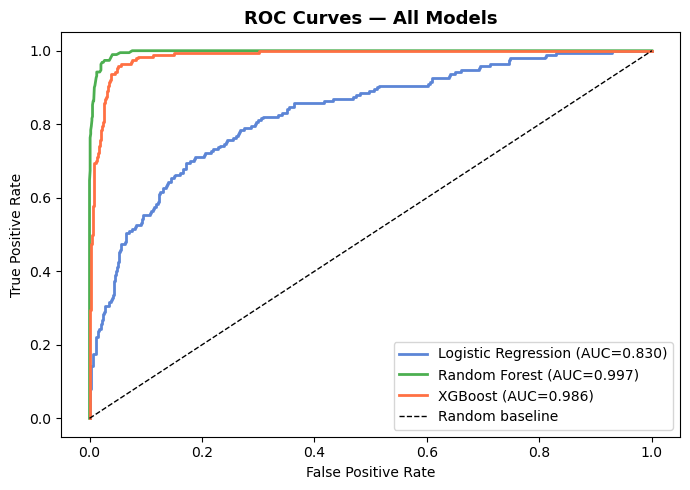

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

for model, name, color in [
    (lr,  'Logistic Regression', '#5C85D6'),
    (rf,  'Random Forest',       '#4CAF50'),
    (xgb, 'XGBoost',             '#FF7043')
]:
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0,1], [0,1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/processed/plot_08_roc_curves.png')
plt.show()

In [13]:
joblib.dump(rf, '../models/best_model.pkl')
print("Best model (Random Forest) saved ✓")
print(f"ROC-AUC: 0.9968 | F1: 0.9372 | Recall: 0.9421")

Best model (Random Forest) saved ✓
ROC-AUC: 0.9968 | F1: 0.9372 | Recall: 0.9421
